In [82]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [83]:
# Lecture du dataset

In [84]:
X = pd.read_csv("Vins.csv",delimiter=";", decimal=",")

X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Alcohol        175 non-null    float64
 1   Total_Phenols  175 non-null    float64
 2   Flavanoids     175 non-null    float64
 3   OD280          175 non-null    float64
 4   Proline        175 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 7.0 KB


In [85]:
# Uniquement des données numériques

In [86]:
# Pas de doublons. Par défaut, on les enlève

In [87]:
X.drop_duplicates(keep="last", inplace=True)
display(len(X))

175

In [88]:
# Verification pour les données manquantes

X.isnull().sum()

Alcohol          0
Total_Phenols    0
Flavanoids       0
OD280            0
Proline          0
dtype: int64

In [13]:
# Les boxplot donnent une bonne indication pour la présence d'outliers sur chaque variable

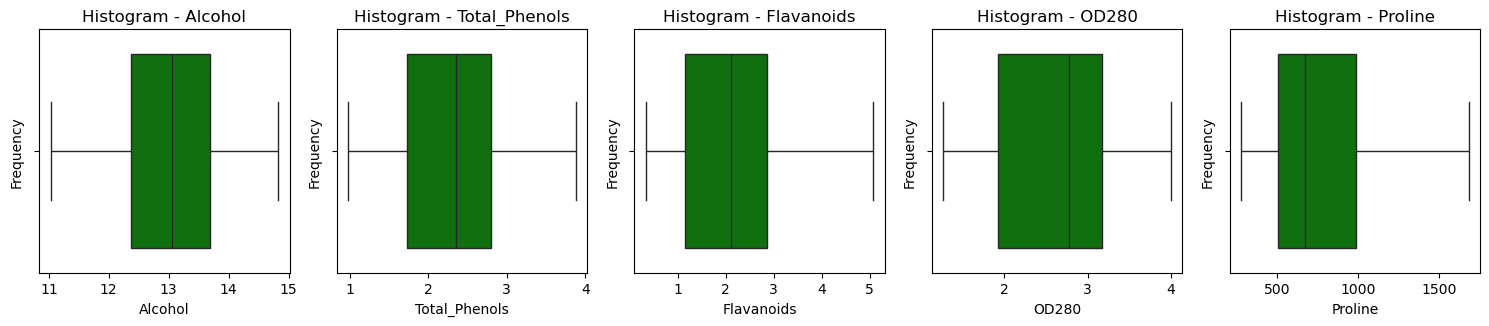

In [14]:
plt.figure(figsize=(15, 15))
num_rows = len(X.columns)

for i, column in enumerate(X.columns, 1):
    plt.subplot(num_rows, 5, i)
    sns.boxplot(x=X[column], color='green')
    plt.title(f'Histogram - {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [15]:
# Quelques outliers. On peut choisir de les garder car ils ne sont pas en grand nombre. Il est préférable de standardiser avec 
# RobustScaler dans ce cas, même si ça va réduire la variance expliquée sur le 1er axe en cas de réduction de dimension.

# L'utilisation de StandardScaler est OK car peu d'outliers et la visualisation des distributions ci-dessous montre des distributions 
# OK pour des méthodes peu perturbées par des écarts a la normalité (ACP et Clustering).


In [16]:
# Visualisation des distributions 1 : utilisation de seaborn et histplot avec un découpage des sections des histogrammes peu précis 
# (bins=5) pour voir l'allure très globale. La variable 'Malic Acid' décroit et pourrait être transformée avec un log. 

# Visualisation des distributions 2 : Un découpage des sections plus précis permet de voir des mélanges de populations éventuelles.
# Le tracé de la courbe de distribution permet une meilleure visualisation. On remarque que la variable 'Malic Acid' se visualise 
# maintenant avec une distribution plus gaussienne (mais longue queue de gaussienne). 

# Des transformation log ou racines cubiques pourraient être OK. Mais ce n'est pas demandé ici. 

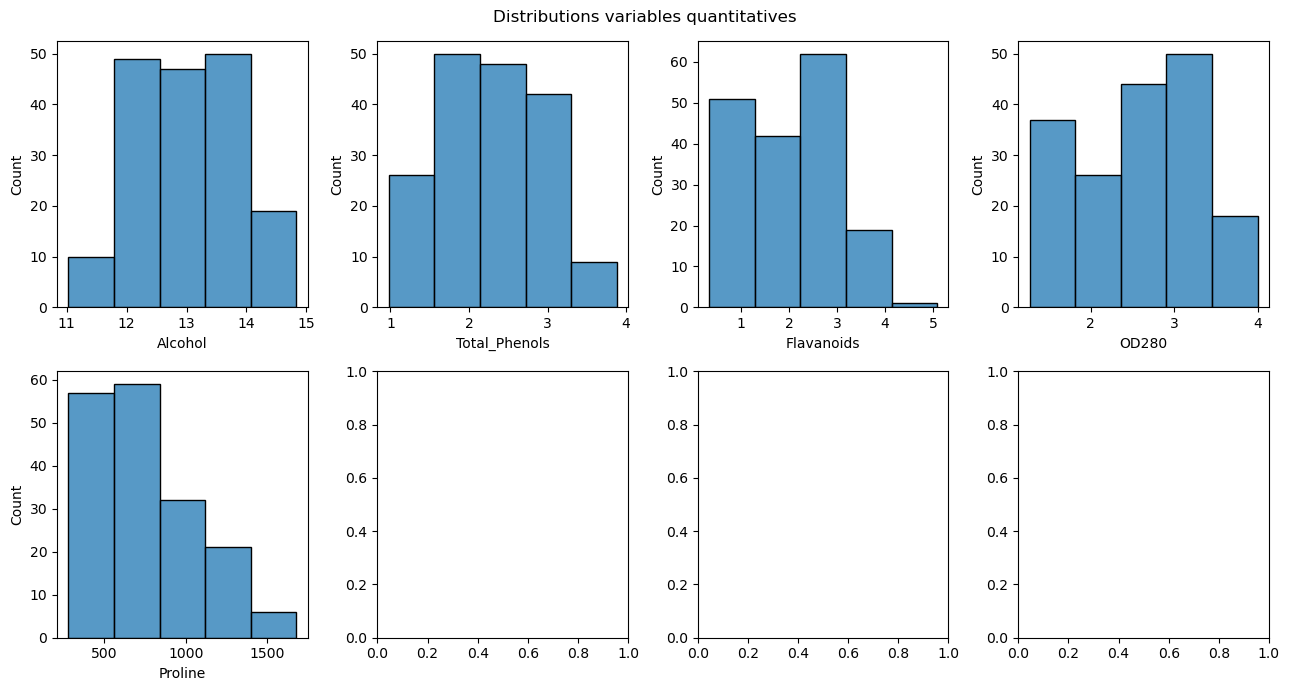

In [17]:

NUM_COLS = 4
NUM_ROWS = math.ceil(X.shape[1] / NUM_COLS)

_, axes = plt.subplots(NUM_ROWS, NUM_COLS, figsize=(13, 7))

for col, ax in zip(X, axes.flatten()):
    sns.histplot(x=col, data=X, ax=ax, bins=5)

plt.suptitle("Distributions variables quantitatives")
plt.tight_layout()
plt.show()


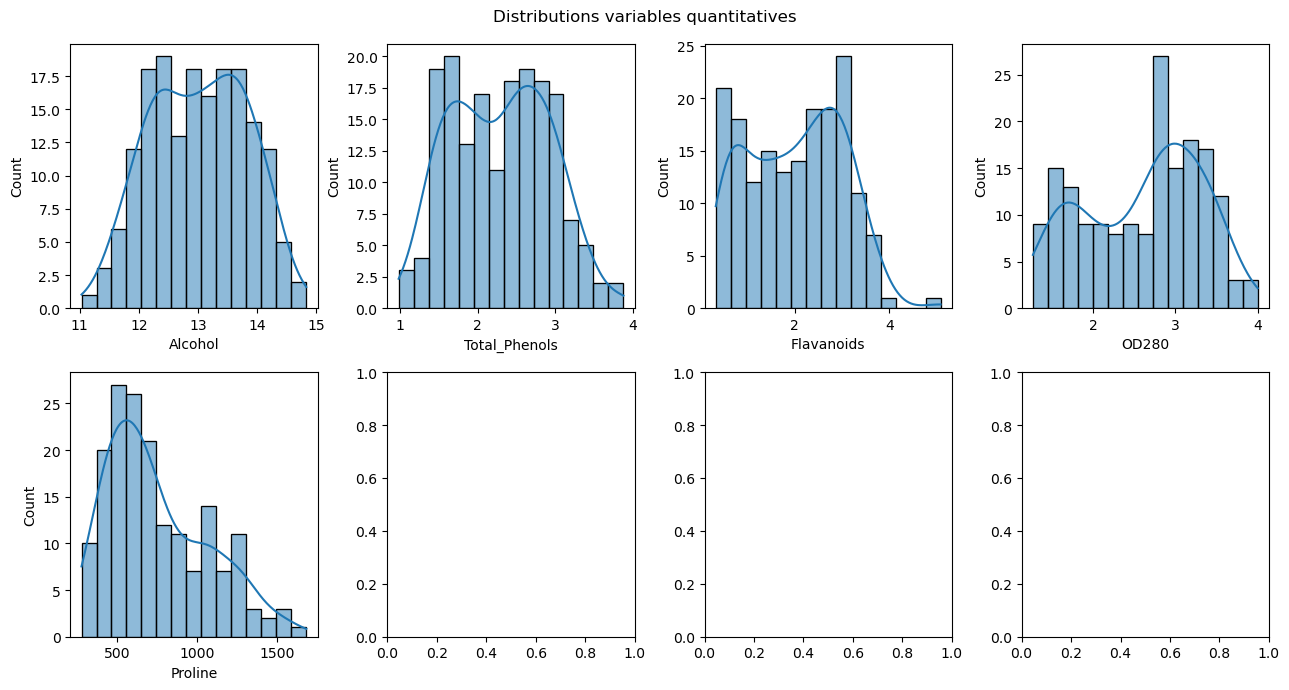

In [18]:
NUM_COLS = 4
NUM_ROWS = math.ceil(X.shape[1] / NUM_COLS)

_, axes = plt.subplots(NUM_ROWS, NUM_COLS, figsize=(13, 7))

for col, ax in zip(X, axes.flatten()):
    sns.histplot(x=col, data=X, kde=True, bins=15,ax=ax)

plt.suptitle("Distributions variables quantitatives")
plt.tight_layout()
plt.show()


In [19]:
# 2. On va regarder les corrélations. 
# Il est logique de regarder les corrélations de Spearman si on a décidé d'utiliser RobustScaler ou Pearson pour StandardScaler. 
# Les informations données seront adéquates dans les 2 cas (forces des corrélations, sans aller dans le détail).

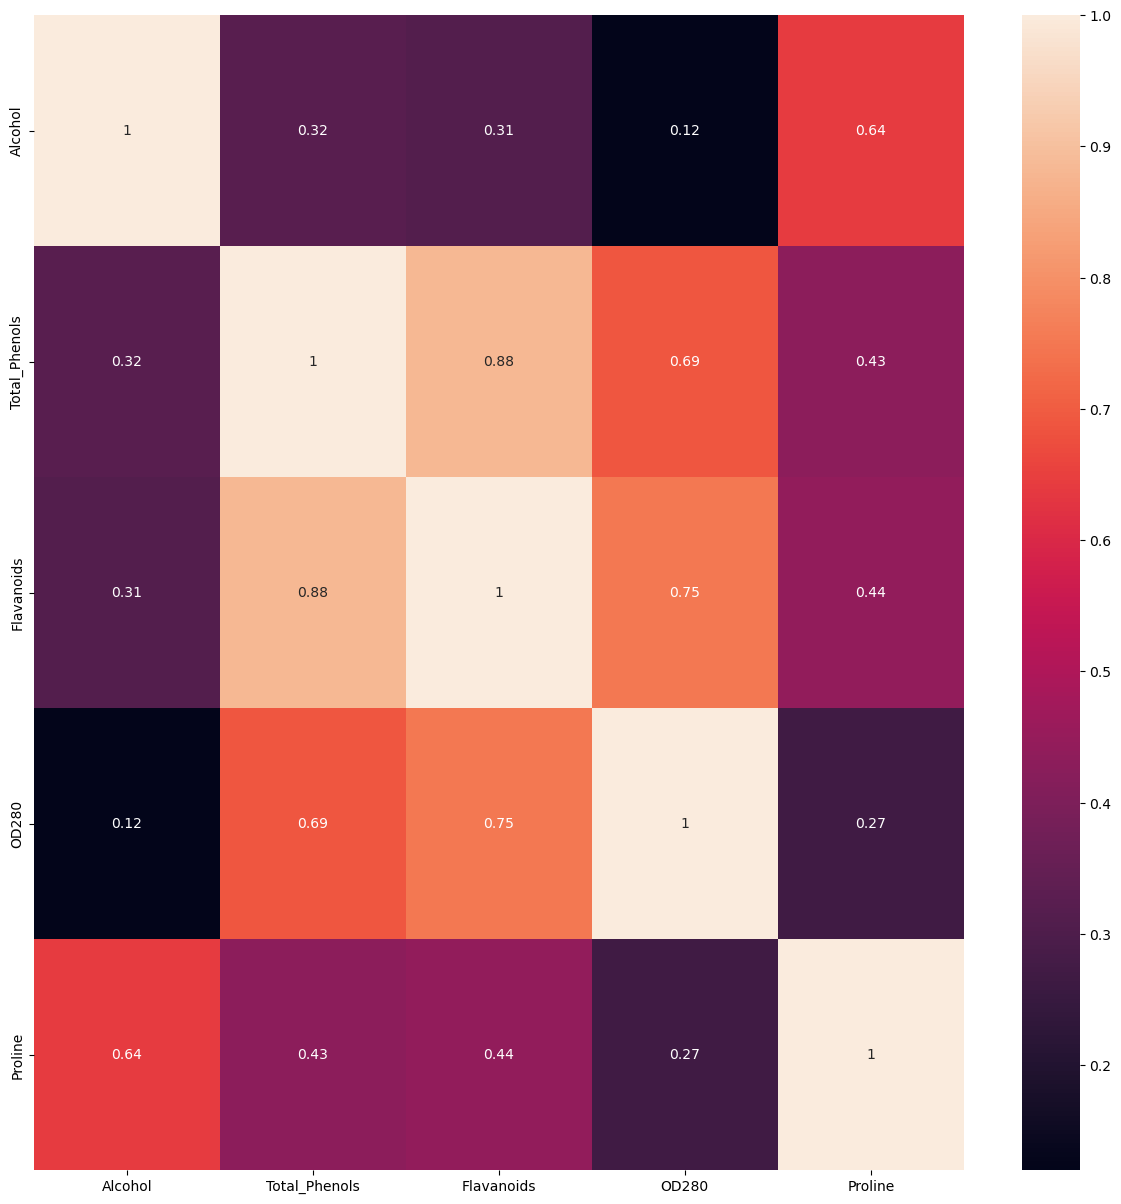

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt


corr = X.corr(method="spearman")
corr = corr.round(2)
f,ax = plt.subplots(figsize=(15,15))
sns.heatmap(corr, annot=True)

plt.show()

In [89]:
from sklearn.preprocessing import StandardScaler
rc = StandardScaler()
Z = rc.fit_transform(X)
Z1 = pd.DataFrame(data = Z, columns = X.columns,index=X.index)
Z1.head()

,Alcohol,Total_Phenols,Flavanoids,OD280,Proline
0,1.507206,0.810119,1.038779,1.855166,0.997961
1,0.233058,0.571260,0.739114,1.123075,0.950203
2,0.183576,0.810119,1.218577,0.799266,1.380021
3,1.680391,2.482134,1.468297,1.193469,2.319254
4,0.282539,0.810119,0.669193,0.461378,-0.052706


In [90]:
Z1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Alcohol        175 non-null    float64
 1   Total_Phenols  175 non-null    float64
 2   Flavanoids     175 non-null    float64
 3   OD280          175 non-null    float64
 4   Proline        175 non-null    float64
dtypes: float64(5)
memory usage: 7.0 KB


In [25]:
# on va réduire les dimensions

In [26]:
import sklearn as sk

In [27]:
from sklearn.decomposition import PCA

In [28]:
print(PCA)

<class 'sklearn.decomposition._pca.PCA'>


In [29]:
acp=PCA(svd_solver='full')
print(acp)

PCA(svd_solver='full')


In [30]:
coord=acp.fit_transform(Z1)

In [31]:
print(coord)

[[ 2.64793565e+00  3.91435908e-01 -5.49163342e-01  9.85664556e-01
  -8.18050067e-02]
 [ 1.65156682e+00 -1.19308693e-01  3.42803472e-01  4.76627188e-01
  -6.73313484e-02]
 [ 2.04434877e+00  2.84557479e-02  6.98795932e-01  3.66200056e-02
   2.19955665e-01]
 [ 4.03579883e+00  1.02590555e+00  1.91182444e-01 -4.41978260e-01
  -6.09799433e-01]
 [ 1.03578699e+00 -3.21731314e-01 -3.95513424e-01 -2.58112288e-01
  -1.30362984e-02]
 [ 3.02559432e+00  1.36748190e+00  4.82399028e-01 -5.21455874e-01
   2.39057963e-02]
 [ 2.25787499e+00  1.29227301e+00  1.99860389e-03  1.14086542e+00
  -1.77313545e-01]
 [ 2.22422291e+00  9.84106397e-01  2.48883029e-01  9.93749045e-01
  -2.94196324e-01]
 [ 2.11198623e+00  1.52944668e+00 -8.74014177e-01 -2.84265781e-02
   2.56439052e-01]
 [ 2.44961602e+00  1.77844426e-01 -2.85473975e-01  3.37410846e-01
  -6.13660211e-02]
 [ 2.97383293e+00  1.29350017e+00  7.18351137e-01  1.46272318e-01
   1.21992642e-01]
 [ 1.37201367e+00  1.58818030e+00  3.86758745e-01  6.09623621e-01

In [32]:
print(acp.explained_variance_ratio_)

[0.6134339  0.24649512 0.06119981 0.05511101 0.02376016]


In [33]:
# Les Valeurs propres
eigval = acp.explained_variance_
print([eigval])

[array([3.08479689, 1.2395588 , 0.30775768, 0.2771387 , 0.11948356])]


In [34]:
# Si on utilise StandardScaler, la premiere VP est supérieure a 4 

In [35]:
# on compare au cutoff de Saporta (1+ sqrt(p-1/n-1))
# On garde 2 facteurs 

n=Z1.shape[0]
p=Z1.shape[1]
Saporta=1+ np.sqrt((p-1)/(n-1))
print(Saporta)

1.1516196087157806


In [36]:
#  On va tracer les VP en fonction des CP

5


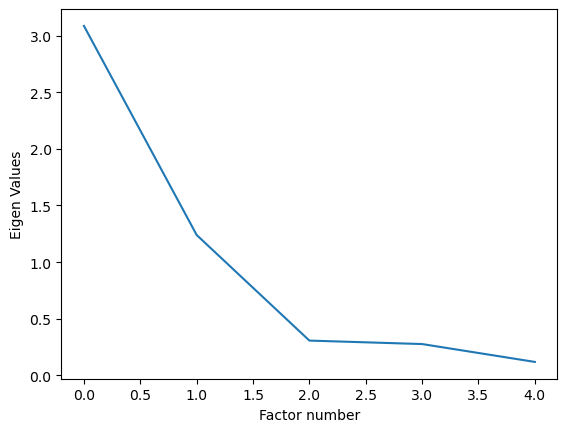

In [37]:
#nombre de variables
p = Z1.shape[1]
print(p)
#nombre d'observations
n = Z1.shape[0]
#matrice des X
X = Z1.values

import matplotlib.pyplot as plt
plt.plot(np.arange(p),eigval)
plt.ylabel("Eigen Values")
plt.xlabel("Factor number")
plt.show()

In [38]:
#  le meilleur coude est pour 4CP mais les CP 3 et 4 ont des valeurs propres inférieures au cutoff de Saporta. Pour 2 CP on a également
# un coude et les VP sont OK. On garde 2CP! On va perdre beaucoup de disparité entre individus mais on va garder les informations 
# globales qui vont nous permettre de distinguer des groupes distincts de vins de façon significatives (sans overfitting)

In [39]:
acp=PCA(n_components=2,svd_solver='full')
coord=acp.fit_transform(Z1)
print(coord)

[[ 2.64793565  0.39143591]
 [ 1.65156682 -0.11930869]
 [ 2.04434877  0.02845575]
 [ 4.03579883  1.02590555]
 [ 1.03578699 -0.32173131]
 [ 3.02559432  1.3674819 ]
 [ 2.25787499  1.29227301]
 [ 2.22422291  0.9841064 ]
 [ 2.11198623  1.52944668]
 [ 2.44961602  0.17784443]
 [ 2.97383293  1.29350017]
 [ 1.37201367  1.5881803 ]
 [ 1.84563842  1.0849535 ]
 [ 2.76426265  1.43365884]
 [ 3.46892386  1.51880583]
 [ 2.06079239  0.86861365]
 [ 2.19187739  1.50328533]
 [ 2.03451853  0.80013342]
 [ 3.61504594  1.59110807]
 [ 1.69290674 -0.10489074]
 [ 2.29798636 -0.15828072]
 [ 0.88071641 -0.7050447 ]
 [ 2.22429714 -0.060883  ]
 [ 1.28357941 -0.47188232]
 [ 1.57644757 -0.34543912]
 [ 1.12120859 -0.44878701]
 [ 2.05511026  0.27552672]
 [ 1.09436136  0.90595821]
 [ 2.06661756  0.12566707]
 [ 1.81859327  0.57200425]
 [ 2.25608228  0.89192682]
 [ 2.46951383  1.06983212]
 [ 1.17987529  0.60027112]
 [ 2.07698049  0.81045197]
 [ 1.11752283  0.67127711]
 [ 1.77932807 -0.18176302]
 [ 0.97736715  0.08307849]
 

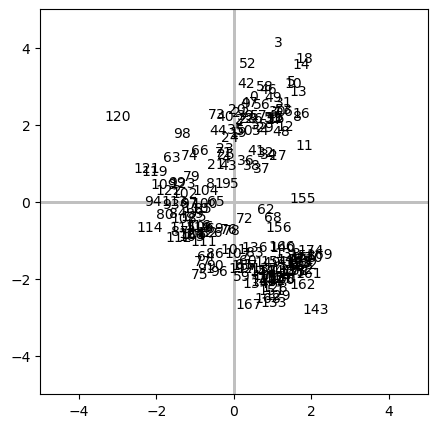

In [40]:
#On va projeter les vins sur les 2CP qui vont constituer les deux seules dimensions dans notre étude de clustering.¶

f,ax = plt.subplots(figsize=(5,5))

ax.set_xlim(-5,5) 
ax.set_ylim(-5,5) 
n = Z1.shape[0]

for i in range(n): 
    plt.annotate(Z1.index[i],(coord[i,1],coord[i,0])) 
    plt.plot([-5,5],[0,0],color='silver',linestyle='-',linewidth=1) 
    plt.plot([0,0],[-5,5],color='silver',linestyle='-',linewidth=1) 
    
plt.show()

In [91]:
from sklearn.cluster import KMeans
from sklearn import metrics 
wcss=[]
res=[]
figsize=(9, 7)

In [92]:
# La comparaison des Inerties globales inter et intra clusters va permettre de trouver le nombre optimal de clusters.

# On souhaite avoir un score silhouette max (il se situe théoriquement entre -1 et 1) et une inertie globale 
# intra clusters minimale (WCSS)
# WCSS représente l'inertie des individus de chaque cluster, regroupés de manière globulaire autours du centre de gravité du cluster)

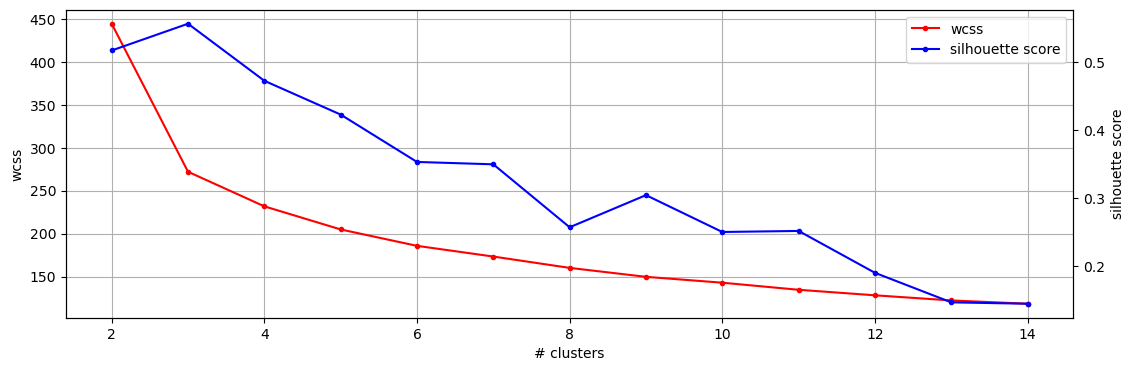

In [107]:
import warnings
warnings.filterwarnings('ignore') 

wcss=[] 
res=[] 

clusters_range = range(2,15)
for k in clusters_range:
    km = KMeans(n_clusters=k, n_init=20, max_iter=100)
    km.fit(Z1)
    wcss.append(km.inertia_)
    res.append(metrics.silhouette_score(coord,km.labels_) )
    
_, ax1 = plt.subplots(figsize=figsize)
    
ax1.plot(clusters_range, wcss, label="wcss", color="red", marker=".")
ax1.set_xlabel("# clusters")
ax1.set_ylabel("wcss")
ax1.grid(True)
    
ax2 = plt.gca().twinx()
ax2.plot(clusters_range, res, label="silhouette score", color="blue", marker=".")
ax2.set_ylabel("silhouette score")

g1, gl1 = ax1.get_legend_handles_labels()
g2, gl2 = ax2.get_legend_handles_labels()
plt.legend(g1 + g2, gl1 + gl2)

plt.show()

In [50]:
# C'est pour 3 clusters que l'on a le max de ScoreSilhouette et un écart ScoreSilhouette et WCSS max.

In [94]:
km = KMeans(n_clusters=3,n_init=20,max_iter=300) 
km.fit(Z1)
km.labels_
cluster_labels = km.predict(Z1)
km.inertia_



272.05000796384627

In [95]:
from sklearn.metrics import silhouette_score
score=silhouette_score(Z1,cluster_labels)
score

np.float64(0.4348926535396855)

In [96]:
cluster_count = 3
km = KMeans(n_clusters=cluster_count) 
km.fit(Z1) 
km.labels_
cluster_labels = km.fit_predict(Z1)
cluster_labels


df_clustered=Z1.copy()
df_clustered=pd.DataFrame(df_clustered)
df_clustered["cluster"]=cluster_labels
df_clustered


,Alcohol,Total_Phenols,Flavanoids,OD280,Proline,cluster
0,1.507206,0.810119,1.038779,1.855166,0.997961,2
1,0.233058,0.571260,0.739114,1.123075,0.950203,2
2,0.183576,0.810119,1.218577,0.799266,1.380021,2
3,1.680391,2.482134,1.468297,1.193469,2.319254,2
4,0.282539,0.810119,0.669193,0.461378,-0.052706,2
...,...,...,...,...,...,...
170,0.863947,-0.973363,-1.408479,-1.213983,-0.036787,0
171,0.480465,-0.782275,-1.268635,-1.467399,-0.004949,0
172,0.319650,-1.116678,-1.328568,-1.467399,0.265678,0
173,0.195947,-1.021134,-1.338557,-1.382927,0.281597,0


In [1047]:
# On peut regarder les ScoreSilhouette (la métrique de validation le plus utilisée) pour chaque cluster formé.
# On utilise la fonction 'sample_silhouette_values' 

In [97]:
num_clusters=3
sample_silhouette_values = metrics.silhouette_samples(Z1, km.labels_)

moy_Score_cluster = []
for i in range(num_clusters):
    moy_Score_cluster.append(sample_silhouette_values[km.labels_ == i].mean())
print(moy_Score_cluster)

[np.float64(0.4716846470517509), np.float64(0.32876817602044933), np.float64(0.4954634923880633)]


In [98]:
# Deux clusters bien séparés et un troisième un peu moins détaché des autres (peut être une plus grande inertie intra)

#  On va projet des couleurs de clusters sur le graphe des CP 

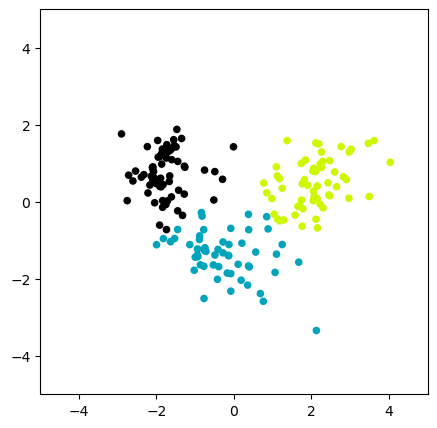

In [99]:
import matplotlib.cm as cm

f,ax = plt.subplots(figsize=(5,5))
#fig, axes = plt.plot(figsize=(12,12))
ax.set_xlim(-5,5)

ax.set_ylim(-5,5)
n = coord.shape[0]

color = cm.nipy_spectral(cluster_labels/3)

# Traçage du nuage de points
for k in range(3):
    is_kth_cluster = (cluster_labels==k)
    ax.scatter(coord[is_kth_cluster,0],coord[is_kth_cluster,1],c=color[is_kth_cluster],s=20)

#for i in range(n):
 #   plt.annotate(Xindex.index[i],coord[i,0],coord[i,1])
#plt.scatter(coord[:,0], coord[:,1], c=cluster_labels)

# On peut maintenant caractériser chaque cluster en identifiant la moyenne des variables initiales pour les vins de chaque cluster et les comparer.
# On peut également regarder quel est l'impact de chaque variable dans le clustering en calculant, pour chacune, le rapport de
# la variance globale de la variable (TSS) vs la variance au sein des clusters (BSS)

In [100]:

#moyenne par variable
m = np.mean(Z1)

n=X.shape[0]

TSS = Z1.shape[0]*Z1.var(ddof=0)

#data.frame conditionnellement aux groupes
gb = Z1.groupby(cluster_labels)


#effectifs conditionnels
nk = gb.size()
print("nk")
print(nk)

#moyennes conditionnelles
mk = gb.mean()

print("mk")
print(mk)

#pour chaque groupe écart à la moyenne par variable
EMk = (mk-m)**2

#pondéré par les effectifs du groupe
EM = EMk.multiply(nk,axis=0)

BSS = np.sum(EM, axis=0)

R2 = BSS/TSS

print("R2")
print(R2)


nk
0    62
1    54
2    59
dtype: int64
mk
    Alcohol  Total_Phenols  Flavanoids     OD280   Proline
0  0.050096      -0.953586   -1.108492 -1.147905 -0.434048
1 -1.063999       0.104453    0.209338  0.459814 -0.765179
2  0.921186       0.906473    0.973259  0.785426  1.156451
R2
Alcohol          0.636315
Total_Phenols    0.602556
Flavanoids       0.768205
OD280            0.740059
Proline          0.698302
dtype: float64


In [59]:
#On voit des caractéristiques de chaque cluster. Certaines variables ne séparent qu'un cluster vs les 2 autres (eg: ash)
# Toutes les variables jouent sur le clustering.
# Les R2 indiquent avec BSS:TSS (BSS est le calcul par variable de la dispersion entre clusters) les variables qui influencent
# le plus les séparations des vins.

# Les 3 variables les plus importantes sont Flavonoids, OD280 et Proline.


# On va aintenant utiliser CAH. Les 2 librairies vont être utilisées pour pratique

# La méthode CAH mesure des distances indiquant des similarités entre individus. Le résultat final est le dendrogramme et 

# le coeff de correlation (c) "cophenic" est la mesure de ressemblance entre individus du fait du clustering. Ce sont ces distances 
# qui sont reliées aux "heights" donc distances donc gain en inertie entre clusters.


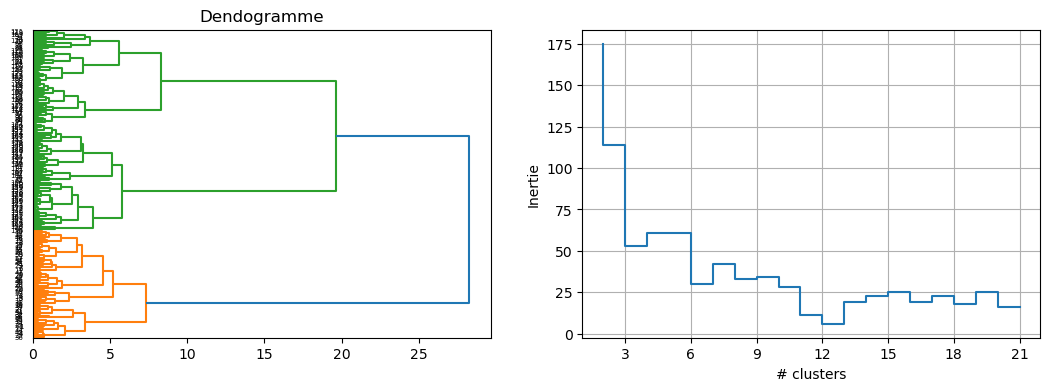

In [101]:
from matplotlib.ticker import MaxNLocator
#librairies pour la CAH
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist

#générer la matrice des liens
Z = linkage(Z1,method='ward',metric='euclidean')

c, coph_dists = cophenet(Z, pdist(Z1))


figsize=(13, 4) 
num_clusters=20
    
plt.figure(figsize=figsize)
plt.subplot(121)
dendrogram(Z,orientation='right')
plt.title("Dendogramme")
        
cluster_inertias = Z[-num_clusters:, 3]
cluster_inertias = cluster_inertias[::-1]
    
plt.subplot(122)
plt.step(range(2, len(cluster_inertias) + 2), cluster_inertias)
plt.xlabel("# clusters")
plt.ylabel("Inertie")
plt.grid()
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    
plt.show()


In [61]:
# On voit que le gain d'inertie le plus important est quand on coupe a 3 clusters.

In [62]:
# On peut tagger les clusters et calculer les métriques de validations

In [65]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')
cluster.fit_predict(Z1)
labels=cluster.labels_


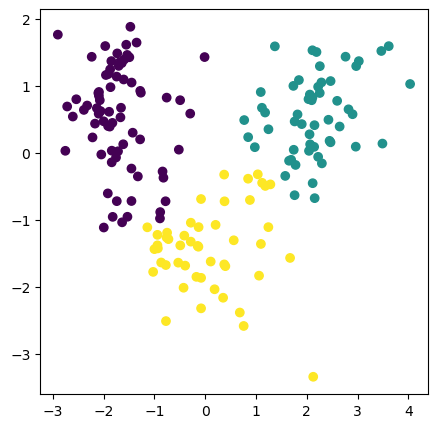

In [102]:
plt.figure(figsize=(5, 5))

for k in range(3):
    is_kth_cluster = (labels==k)
    ax.scatter(coord[is_kth_cluster,0],coord[is_kth_cluster,1],c=color[is_kth_cluster],s=50)

n = X.shape[0]
#for i in range(n):
#    plt.annotate(X4.index[i],(coord[i,0],coord[i,1]))
plt.scatter(coord[:,0], coord[:,1], c=labels)

In [104]:
from sklearn.metrics import silhouette_score
score=silhouette_score(Z1,labels)
score

np.float64(0.4187164020183547)

In [105]:
# On peut regarder également ici les différences de moyennes des variables initiales dans les clusters

In [106]:
#moyenne par variable
m = np.mean(Z1)

n=X.shape[0]

TSS = Z1.shape[0]*Z1.var(ddof=0)

#data.frame conditionnellement aux groupes
gb = Z1.groupby(labels)


#effectifs conditionnels
nk = gb.size()
print("nk")
print(nk)

#moyennes conditionnelles
mk = gb.mean()

print("mk")
print(mk)

#pour chaque groupe écart à la moyenne par variable
EMk = (mk-m)**2

#pondéré par les effectifs du groupe
EM = EMk.multiply(nk,axis=0)

BSS = np.sum(EM, axis=0)

R2 = BSS/TSS

print("R2")
print(R2)

nk
0    72
1    55
2    48
dtype: int64
mk
    Alcohol  Total_Phenols  Flavanoids     OD280   Proline
0 -0.104550      -0.924264   -1.011840 -1.009452 -0.471823
1  0.966733       0.923324    0.998279  0.778276  1.241495
2 -0.950890       0.328420    0.373899  0.622403 -0.714812
R2
Alcohol          0.546227
Total_Phenols    0.648990
Flavanoids       0.772778
OD280            0.715864
Proline          0.716151
dtype: float64


In [72]:
# On remarque que ce ne sont pas 100% les mêmes variables vs KMeans qui sont indiquées les plus importantes. 

# On a bien 'Flavonoid' et 'OD280' retrouvée les 2 plus importantes mais également 'Total_Phenols' a la place de 'Proline'.

# La variable Proline doit être assez typée pour les vins 'Borderline' d'un ou plusieurs clusters.

# Le classement des vins en frontière de clusters est donc différent et on le voit bien sur les graphes des CP

# En rajoutant une colonne 'Cluster_CAH', on pourra comparer les individus de cette colonne de ceux dans la colonne 'cluster'
# du KMeans


In [73]:
df_clustered["cluster_CAH"]=labels
df_clustered.head()

,Alcohol,Total_Phenols,Flavanoids,OD280,Proline,cluster,cluster_CAH
0,1.507206,0.810119,1.038779,1.855166,0.997961,3,1
1,0.233058,0.571260,0.739114,1.123075,0.950203,0,1
2,0.183576,0.810119,1.218577,0.799266,1.380021,3,1
3,1.680391,2.482134,1.468297,1.193469,2.319254,3,1
4,0.282539,0.810119,0.669193,0.461378,-0.052706,0,2


In [74]:
## On regarde les vins classés différemment selon les 2 méthodes

# Auparavant, on va intituler le même numéro de cluster dans les 2 méthodes (dans notre cas, les 1 et 2 sont inversés pour KMeans et CAH)

df_clustered["cluster_CAH"] = df_clustered["cluster_CAH"].replace(1, 3)
df_clustered["cluster_CAH"] = df_clustered["cluster_CAH"].replace(2, 1)
df_clustered["cluster_CAH"] = df_clustered["cluster_CAH"].replace(3, 2)

display(df_clustered)

,Alcohol,Total_Phenols,Flavanoids,OD280,Proline,cluster,cluster_CAH
0,1.507206,0.810119,1.038779,1.855166,0.997961,3,2
1,0.233058,0.571260,0.739114,1.123075,0.950203,0,2
2,0.183576,0.810119,1.218577,0.799266,1.380021,3,2
3,1.680391,2.482134,1.468297,1.193469,2.319254,3,2
4,0.282539,0.810119,0.669193,0.461378,-0.052706,0,1
...,...,...,...,...,...,...,...
170,0.863947,-0.973363,-1.408479,-1.213983,-0.036787,2,0
171,0.480465,-0.782275,-1.268635,-1.467399,-0.004949,2,0
172,0.319650,-1.116678,-1.328568,-1.467399,0.265678,2,0
173,0.195947,-1.021134,-1.338557,-1.382927,0.281597,2,0


In [75]:
df_diff_Clustered = df_clustered.loc[~(df_clustered['cluster'] == df_clustered['cluster_CAH'])]
print(df_diff_Clustered.shape)
display( df_diff_Clustered )

(141, 7)


,Alcohol,Total_Phenols,Flavanoids,OD280,Proline,cluster,cluster_CAH
0,1.507206,0.810119,1.038779,1.855166,0.997961,3,2
1,0.233058,0.571260,0.739114,1.123075,0.950203,0,2
2,0.183576,0.810119,1.218577,0.799266,1.380021,3,2
3,1.680391,2.482134,1.468297,1.193469,2.319254,3,2
4,0.282539,0.810119,0.669193,0.461378,-0.052706,0,1
...,...,...,...,...,...,...,...
170,0.863947,-0.973363,-1.408479,-1.213983,-0.036787,2,0
171,0.480465,-0.782275,-1.268635,-1.467399,-0.004949,2,0
172,0.319650,-1.116678,-1.328568,-1.467399,0.265678,2,0
173,0.195947,-1.021134,-1.338557,-1.382927,0.281597,2,0


In [76]:
# Il y a 24 vins classés différemment donc 13%. 87% de vins classés de la même façon par KMeans et CAH

# Sachant que ce dataset comporte 3 vignerons différents et que nous avons éliminé 45% de la variance de ces vins, il est 
# fort probable que les 3 clusters soient reliés aux spécificités des vignerons. Pour avoir un clustering plus précis il 
# faudrait rajouter des vins ou commencer par éliminer des outliers et refaire un clustering en tentant de cerner plus de clusters.
# 6 clusters pourraient être envisagés en regardant les scores silhouette de KMeans